In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import mne
import matplotlib.pyplot as plt
import warnings
from tqdm import tqdm
from scipy.stats import ttest_ind
import os

# Настройка отображения
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
warnings.filterwarnings('ignore')

In [2]:
def load_and_prepare_data(filepath):
    """Загрузка данных и подготовка спектров"""
    print("📂 Загрузка данных...")
    
    data = np.load(filepath, allow_pickle=True)
    
    # Собираем все спектры и метки субъектов
    spectra = []
    subject_ids = []
    
    i = 0
    while f'power_{i}' in data:
        if (not int(data[f'subject_id_{i}']) in [6, 22, 27, 34]) and (not (int(data[f'subject_id_{i}']), int(data[f'trial_id_{i}'])) in [(32, 2), (29, 2), (28, 2), (27, 2), (24, 2), (14, 2)]):
            spectra.append(data[f'power_{i}'])
            subject_ids.append(int(data[f'subject_id_{i}']))
        i += 1
    spectra = np.array(spectra)
    subject_ids = np.array(subject_ids)
    
    print(f"✅ Загружено {len(spectra)} спектров")
    print(f"✅ Уникальных субъектов: {len(np.unique(subject_ids))}")
    print(f"✅ Форма спектров: {spectra[0].shape}")
    
    return spectra, subject_ids

def prepare_for_correlation(spectra):
    """Подготовка спектров для корреляционного анализа"""
    # Если спектры многоканальные - усредняем по каналам
    if spectra.ndim == 3:  # (n_samples, n_channels, n_freqs)
        return np.mean(spectra, axis=1)
    elif spectra.ndim == 2:  # (n_samples, n_freqs)
        return spectra
    else:
        raise ValueError(f"Неожиданная размерность: {spectra.ndim}")

In [3]:
filepath = '../Generated/Spectrums/exec_and_rest_fft.npz'
spectra, subject_ids = load_and_prepare_data(filepath)

# Подготавливаем для корреляций
spectra_2d = prepare_for_correlation(spectra)
print(f"\n📊 Данные для корреляций: {spectra_2d.shape}")

📂 Загрузка данных...
✅ Загружено 1155 спектров
✅ Уникальных субъектов: 30
✅ Форма спектров: (63, 381)

📊 Данные для корреляций: (1155, 381)


In [4]:
spectra.shape

(1155, 63, 381)

In [5]:
n_freq_bins = spectra.shape[2]
freqs = np.linspace(2, 40, n_freq_bins)
n_channels = spectra.shape[1]

In [6]:
def compute_correlation_matrix(spectra):
    """
    Вычисление матрицы корреляций Пирсона
    spectra: (n_samples, n_features)
    """
    # Центрируем и нормируем
    X = spectra - np.mean(spectra, axis=1, keepdims=True)
    X_norm = np.linalg.norm(X, axis=1, keepdims=True)
    X_norm[X_norm == 0] = 1
    X_normalized = X / X_norm
    
    # Косинусное сходство = корреляция Пирсона
    corr_matrix = np.dot(X_normalized, X_normalized.T)
    
    # Заполняем диагональ NaN (не будем использовать автокорреляции)
    np.fill_diagonal(corr_matrix, np.nan)
    
    return corr_matrix

def get_intra_inter_correlations(corr_matrix, subject_ids):
    """
    Извлечение внутри- и межсубъектных корреляций
    """
    n = len(subject_ids)
    intra_corrs = []
    inter_corrs = []
    
    for i in range(n):
        for j in range(i + 1, n):
            corr = corr_matrix[i, j]
            if not np.isnan(corr):
                if subject_ids[i] == subject_ids[j]:
                    intra_corrs.append(corr)
                else:
                    inter_corrs.append(corr)
    
    return np.array(intra_corrs), np.array(inter_corrs)


Creating topomap visualizations...
  Creating montage for 63-channel EEG system...
    Created montage with 63 channels
  Processing Delta (1-4 Hz)...
[1.27769494e-03 1.69264764e-04 8.47626507e-05 5.81936387e-04
 1.60100913e-04 8.39552740e-05 7.18031370e-05 4.49810213e-05
 1.34303802e-04 3.43779172e-03 4.16625298e-05 6.89355875e-05
 7.46429359e-05 4.68725630e-05 6.41145307e-05 1.12277194e-04
 1.62234646e-04 1.16796524e-04 5.08629928e-05 9.04094486e-05
 4.74439730e-04 3.91367394e-05 4.12067711e-05 4.33216155e-05
 9.02440457e-04 1.75439884e-04 7.49927349e-05 6.16060352e-05
 7.26012731e-05 4.57244983e-04 9.81564075e-03 4.82993945e-03
 1.74455519e-04 1.64000812e-04 9.62509148e-05 2.28525561e-04
 1.13495902e-04 6.53547395e-05 5.52051097e-05 4.61284726e-05
 1.07032931e-04 7.82457937e-05 5.70805823e-05 7.67544552e-05
 8.52481389e-05 7.08136140e-05 8.49724820e-05 1.17206859e-04
 9.38244848e-05 6.28229536e-05 9.60335092e-05 1.26877567e-04
 4.04123020e-05 1.10823865e-04 4.64157238e-05 5.4018055

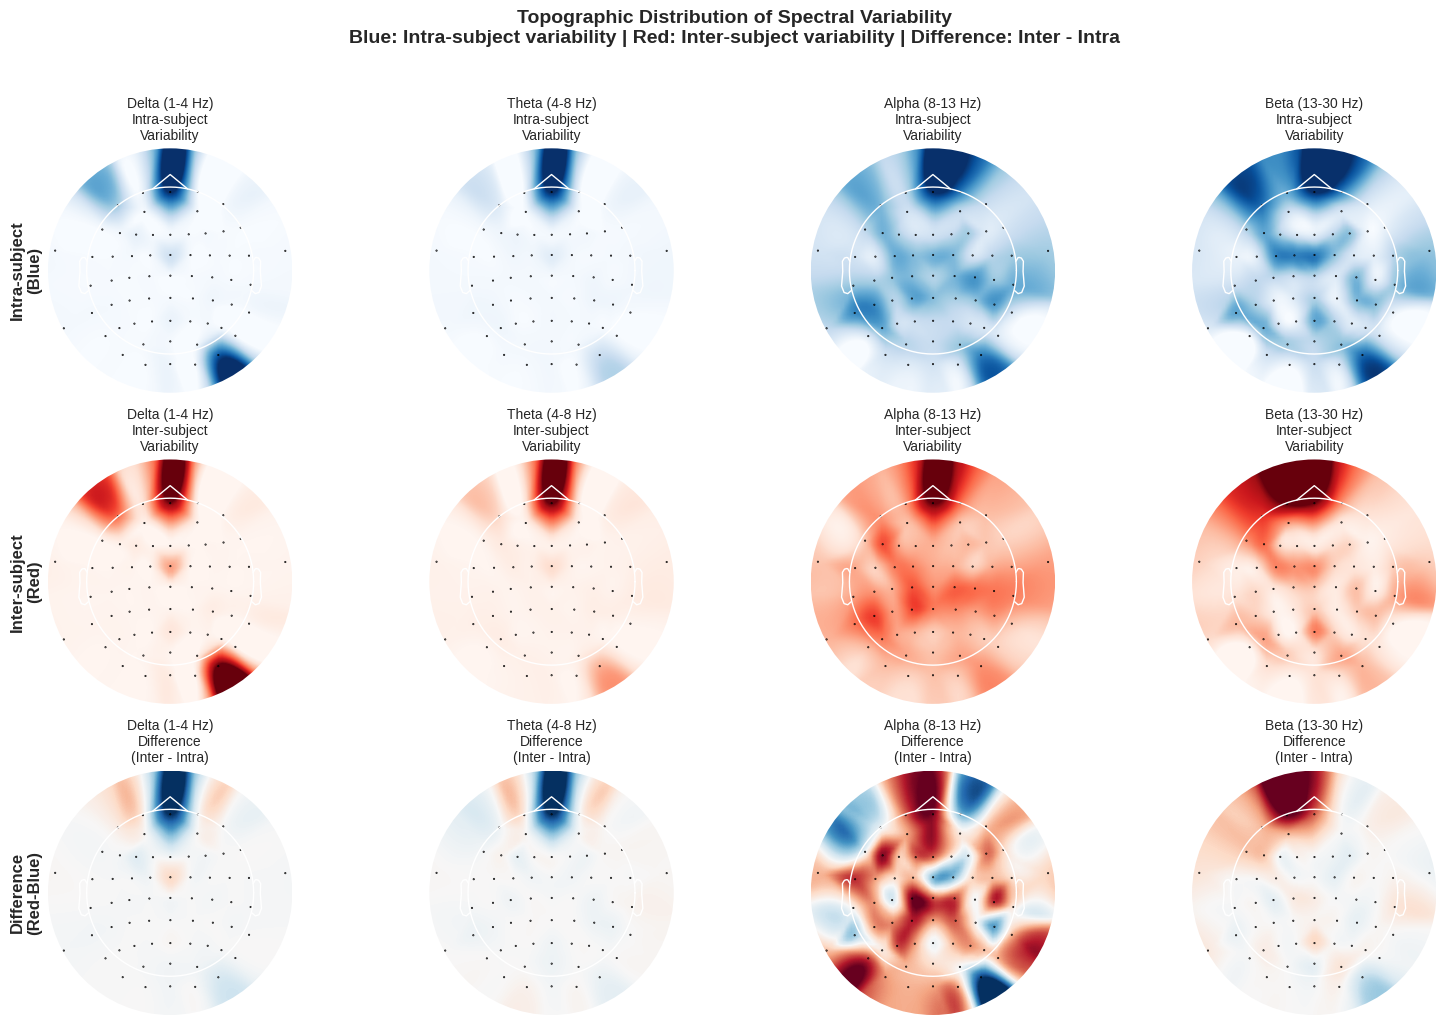

In [7]:
def create_topomap_plots(spectra_list, subject_ids, freqs, n_channels=63):
    """
    Создает топомапы для внутрисубъектных и межсубъектных различий
    
    Args:
        spectra_list: список спектров (n_channels, n_frequencies)
        subject_ids: идентификаторы субъектов
        freqs: частоты
        n_channels: количество каналов
    """
    print("\nCreating topomap visualizations...")
    
    # Проверяем, есть ли многоканальные данные
    if len(spectra_list) == 0 or spectra_list[0].ndim == 1:
        print("  Warning: No multi-channel data available for topomaps")
        return
    
    # Определяем частотные диапазоны
    freq_bands = {
        'Delta (1-4 Hz)': (1, 4),
        'Theta (4-8 Hz)': (4, 8),
        'Alpha (8-13 Hz)': (8, 13),
        'Beta (13-30 Hz)': (13, 30)
    }
    
    # Создаем фигуру для топомапов
    n_bands = len(freq_bands)
    fig, axes = plt.subplots(3, n_bands, figsize=(4*n_bands, 10))
    if n_bands == 1:
        axes = axes.reshape(3, 1)
    
    # Создаем упрощенную информацию о каналах для 63-канальной системы
    print("  Creating montage for 63-channel EEG system...")
    
    # Стандартные названия каналов для 63-канальной системы
    # Базовый набор каналов 10-20 системы
    standard_channels = [
        'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FT7', 'FC3', 'FCz', 
        'FC4', 'FT8', 'T7', 'C3', 'Cz', 'C4', 'T8', 'TP7', 'CP3', 'CPz', 
        'CP4', 'TP8', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'O2', 'Oz'
    ]
    
    # Добавляем дополнительные каналы для 63-канальной системы
    extra_channels = [
        'Fpz', 'AF7', 'AF3', 'AF4', 'AF8', 'F5', 'F1', 'F2', 'F6', 'FC5',
        'FC1', 'FC2', 'FC6', 'C5', 'C1', 'C2', 'C6', 'CP5', 'CP1', 'CP2',
        'CP6', 'P5', 'P1', 'P2', 'P6', 'PO7', 'PO3', 'POz', 'PO4', 'PO8',
        'FT9', 'FT10', 'TP9', 'TP10'
    ]
    
    # Объединяем каналы
    ch_names = standard_channels + extra_channels
    # Берем только первые n_channels каналов
    ch_names = ch_names[:n_channels]
    
    # Создаем info
    info = mne.create_info(ch_names=ch_names, sfreq=250, ch_types='eeg')
    
    # Создаем кастомный montage
    try:
        montage = mne.channels.make_standard_montage('standard_1020')
        montage_ch_names = list(montage.ch_names)
        ch_pos = {}
        
        # Сопоставляем наши каналы с каналами в montage
        for ch in ch_names:
            if ch in montage_ch_names:
                ch_pos[ch] = montage.get_positions()['ch_pos'][ch]
            else:
                # Для каналов, которых нет в стандартном montage
                print(f"    Warning: Channel {ch} not in standard montage, using approximate position")
                ch_pos[ch] = np.array([0, 0, 0])  # Временная позиция
        
        # Создаем кастомный montage
        montage = mne.channels.make_dig_montage(ch_pos=ch_pos)
        info.set_montage(montage)
        print(f"    Created montage with {len(ch_pos)} channels")
        
    except Exception as e:
        print(f"    Error creating montage: {e}")
        print("    Using spherical layout without specific montage")
    
    # Группируем данные по субъектам
    unique_subjects = np.unique(subject_ids)
    subject_groups = {}
    
    for subj in unique_subjects:
        subject_indices = np.where(subject_ids == subj)[0]
        if len(subject_indices) >= 2:  # Нужно хотя бы 2 сессии для внутрисубъектного анализа
            subject_groups[subj] = [spectra_list[i] for i in subject_indices]
    
    # Для каждого частотного диапазона вычисляем средние различия
    for band_idx, (band_name, (low_freq, high_freq)) in enumerate(freq_bands.items()):
        print(f"  Processing {band_name}...")
        
        # Создаем маску для частотного диапазона
        freq_mask = (freqs >= low_freq) & (freqs < high_freq)
        
        # Вычисляем внутрисубъектные различия
        intra_diffs = []
        for subj, subj_spectra in subject_groups.items():
            if len(subj_spectra) >= 2:
                # Усредняем по частотам в диапазоне для каждого канала
                band_spectra = [np.mean(spec[:, freq_mask], axis=1) for spec in subj_spectra]
                # Вычисляем стандартное отклонение между сессиями для каждого канала
                if len(band_spectra) > 1:
                    band_array = np.array(band_spectra)  # (n_sessions, n_channels)
                    # Берем только первые n_channels каналов для совместимости с info
                    n_plot_channels = min(band_array.shape[1], len(info['ch_names']))
                    subj_std = np.std(band_array[:, :n_plot_channels], axis=0)
                    intra_diffs.append(subj_std)
        
        # Вычисляем межсубъектные различия
        inter_diffs = []
        subject_means = []
        for subj, subj_spectra in subject_groups.items():
            if len(subj_spectra) >= 1:
                # Усредняем по частотам и по сессиям для каждого субъекта
                band_spectra = [np.mean(spec[:, freq_mask], axis=1) for spec in subj_spectra]
                n_plot_channels = min(band_spectra[0].shape[0], len(info['ch_names']))
                band_spectra_trimmed = [spec[:n_plot_channels] for spec in band_spectra]
                subj_mean = np.mean(band_spectra_trimmed, axis=0)
                subject_means.append(subj_mean)
        
        if len(subject_means) >= 2:
            subject_means_array = np.array(subject_means)  # (n_subjects, n_channels)
            n_plot_channels = min(subject_means_array.shape[1], len(info['ch_names']))
            inter_std = np.std(subject_means_array[:, :n_plot_channels], axis=0)
            inter_diffs = inter_std
        
        # Преобразуем в массивы для визуализации
        n_plot_channels = len(info['ch_names'])
        
        if intra_diffs:
            intra_array = np.array(intra_diffs)
            # Обрезаем или дополняем до нужного количества каналов
            if intra_array.shape[1] >= n_plot_channels:
                intra_mean = np.mean(intra_array[:, :n_plot_channels], axis=0)
            else:
                intra_mean = np.zeros(n_plot_channels)
                intra_mean[:intra_array.shape[1]] = np.mean(intra_array, axis=0)
        else:
            intra_mean = np.zeros(n_plot_channels)
        
        if len(inter_diffs) > 0:
            if len(inter_diffs) >= n_plot_channels:
                inter_mean = inter_diffs[:n_plot_channels]
            else:
                inter_mean = np.zeros(n_plot_channels)
                inter_mean[:len(inter_diffs)] = inter_diffs
        else:
            inter_mean = np.zeros(n_plot_channels)

        print(inter_mean)
        # Вычисляем разницу (красный - синий)
        diff_mean = inter_mean - intra_mean

        print(diff_mean)
        
        # Функция для симметричных пределов цвета
        def sym_vlim(v):
            vmax = np.nanmax(np.abs(v))
            return (-vmax, vmax) if np.isfinite(vmax) and vmax > 0 else (-1, 1)
        
        # 1. Внутрисубъектные различия (синий)
        ax1 = axes[0, band_idx]
        if np.any(intra_mean != 0):
            try:
                # Используем правильный API для plot_topomap
                im1, _ = mne.viz.plot_topomap(intra_mean, info, axes=ax1, show=False, 
                                             cmap='Blues', contours=0, sensors=True)
                ax1.set_title(f'{band_name}\nIntra-subject\nVariability', fontsize=10)
            except Exception as e:
                print(f"    Error plotting intra-subject topomap: {e}")
                ax1.text(0.5, 0.5, 'Plot error', transform=ax1.transAxes, 
                        ha='center', va='center')
                ax1.set_title(f'{band_name}\nIntra-subject\n(Error)', fontsize=10)
        else:
            ax1.text(0.5, 0.5, 'No data', transform=ax1.transAxes, 
                    ha='center', va='center')
            ax1.set_title(f'{band_name}\nIntra-subject\n(No data)', fontsize=10)
        
        # 2. Межсубъектные различия (красный)
        ax2 = axes[1, band_idx]
        if np.any(inter_mean != 0):
            try:
                im2, _ = mne.viz.plot_topomap(inter_mean, info, axes=ax2, show=False, 
                                             cmap='Reds', contours=0, sensors=True)
                ax2.set_title(f'{band_name}\nInter-subject\nVariability', fontsize=10)
            except Exception as e:
                print(f"    Error plotting inter-subject topomap: {e}")
                ax2.text(0.5, 0.5, 'Plot error', transform=ax2.transAxes, 
                        ha='center', va='center')
                ax2.set_title(f'{band_name}\nInter-subject\n(Error)', fontsize=10)
        else:
            ax2.text(0.5, 0.5, 'No data', transform=ax2.transAxes, 
                    ha='center', va='center')
            ax2.set_title(f'{band_name}\nInter-subject\n(No data)', fontsize=10)
        
        # 3. Разница (красный - синий) с симметричной цветовой шкалой
        ax3 = axes[2, band_idx]
        if np.any(diff_mean != 0):
            try:
                vlim = sym_vlim(diff_mean)
                im3, _ = mne.viz.plot_topomap(diff_mean, info, axes=ax3, show=False, 
                                             cmap='RdBu_r', contours=0, sensors=True)
                ax3.set_title(f'{band_name}\nDifference\n(Inter - Intra)', fontsize=10)
            except Exception as e:
                print(f"    Error plotting difference topomap: {e}")
                ax3.text(0.5, 0.5, 'Plot error', transform=ax3.transAxes, 
                        ha='center', va='center')
                ax3.set_title(f'{band_name}\nDifference\n(Error)', fontsize=10)
        else:
            ax3.text(0.5, 0.5, 'No data', transform=ax3.transAxes, 
                    ha='center', va='center')
            ax3.set_title(f'{band_name}\nDifference\n(No data)', fontsize=10)
    
    # Добавляем заголовки для столбцов
    axes[0, 0].set_ylabel('Intra-subject\n(Blue)', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Inter-subject\n(Red)', fontsize=12, fontweight='bold')
    axes[2, 0].set_ylabel('Difference\n(Red-Blue)', fontsize=12, fontweight='bold')
    
    plt.suptitle('Topographic Distribution of Spectral Variability\n'
                'Blue: Intra-subject variability | Red: Inter-subject variability | Difference: Inter - Intra', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return fig
    
    # Создаем топомапы
topomap_fig = create_topomap_plots(spectra, subject_ids, freqs, n_channels)

In [8]:
def permutation_test(spectra, subject_ids, n_permutations=5000):
    """
    ПРАВИЛЬНЫЙ permutation test: перемешивание меток субъектов
    """
    print(f"\n✅ ЗАПУСК PERMUTATION TEST ({n_permutations} перестановок)")
    
    # Вычисляем матрицу корреляций (один раз!)
    print("  Вычисление матрицы корреляций...")
    corr_matrix = compute_correlation_matrix(spectra)
    
    # Наблюдаемая статистика
    obs_intra, obs_inter = get_intra_inter_correlations(corr_matrix, subject_ids)
    obs_stat = np.mean(obs_intra) - np.mean(obs_inter)
    
    # Информация о структуре данных
    unique_subjects = np.unique(subject_ids)
    subject_sizes = {subj: np.sum(subject_ids == subj) for subj in unique_subjects}
    
    print(f"  Структура данных:")
    print(f"    Всего спектров: {len(subject_ids)}")
    
    print(f"    Субъектов: {len(unique_subjects)}")
    print(f"    Сессий на субъекта: {dict(subject_sizes)}")
    
    # Массив для статистик перестановок
    perm_stats = np.zeros(n_permutations)
    
    for perm in tqdm(range(n_permutations), desc="Перестановки"):
        # 1. Перемешиваем метки субъектов, сохраняя размеры групп
        permuted_labels = subject_ids.copy()
        
        # Получаем все индексы и перемешиваем их
        all_indices = np.arange(len(subject_ids))
        np.random.shuffle(all_indices)
        
        # Назначаем новые метки, сохраняя размеры групп
        start = 0
        for subj in unique_subjects:
            size = subject_sizes[subj]
            permuted_labels[all_indices[start:start + size]] = subj
            start += size
        
        # 2. Собираем внутри- и межсубъектные корреляции с новыми метками
        perm_intra, perm_inter = get_intra_inter_correlations(corr_matrix, permuted_labels)
        
        # 3. Вычисляем статистику
        if len(perm_intra) > 0 and len(perm_inter) > 0:
            perm_stats[perm] = np.mean(perm_intra) - np.mean(perm_inter)
    
    # p-value (односторонний тест: intra > inter)
    p_value = np.sum(perm_stats >= obs_stat) / n_permutations
    
    return {
        'statistic': obs_stat,
        'p_value': p_value,
        'distribution': perm_stats,
        'n_permutations': n_permutations,
        'intra_mean': np.mean(obs_intra),
        'inter_mean': np.mean(obs_inter),
        'intra_corrs': obs_intra,
        'inter_corrs': obs_inter,
        'subject_sizes': subject_sizes,
        'subject_ids': subject_ids
    }

# Запускаем тест
results = permutation_test(spectra_2d, subject_ids, n_permutations=5000)

print(f"\n✅ Результаты permutation test:")
print(f"  p-value = {results['p_value']:.6f}")
print(f"  Статистика = {results['statistic']:.6f}")
print(f"  Среднее intra = {results['intra_mean']:.4f}")
print(f"  Среднее inter = {results['inter_mean']:.4f}")



✅ ЗАПУСК PERMUTATION TEST (5000 перестановок)
  Вычисление матрицы корреляций...
  Структура данных:
    Всего спектров: 1155
    Субъектов: 30
    Сессий на субъекта: {1: 42, 2: 42, 3: 42, 4: 42, 5: 42, 7: 42, 8: 42, 9: 42, 10: 42, 11: 42, 12: 42, 13: 42, 14: 21, 15: 42, 16: 42, 17: 42, 18: 42, 19: 42, 20: 42, 21: 42, 23: 42, 24: 21, 25: 42, 26: 42, 28: 21, 29: 21, 30: 42, 31: 42, 32: 21, 33: 42}


Перестановки: 100%|██████████| 5000/5000 [56:45<00:00,  1.47it/s]


✅ Результаты permutation test:
  p-value = 0.000000
  Статистика = 0.183179
  Среднее intra = 0.6211
  Среднее inter = 0.4380


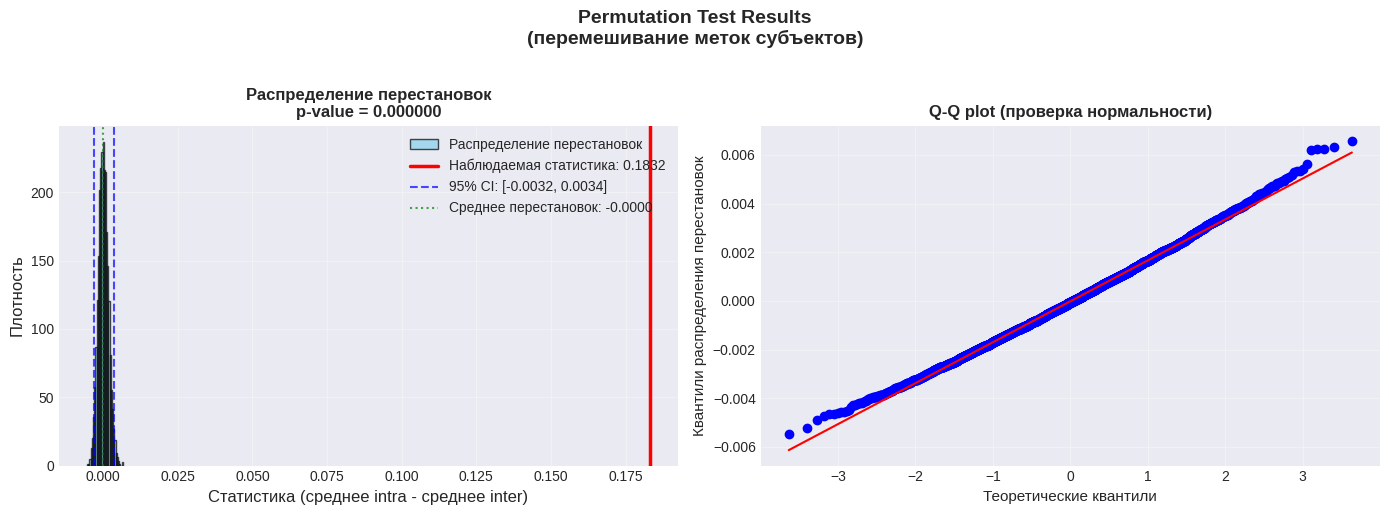

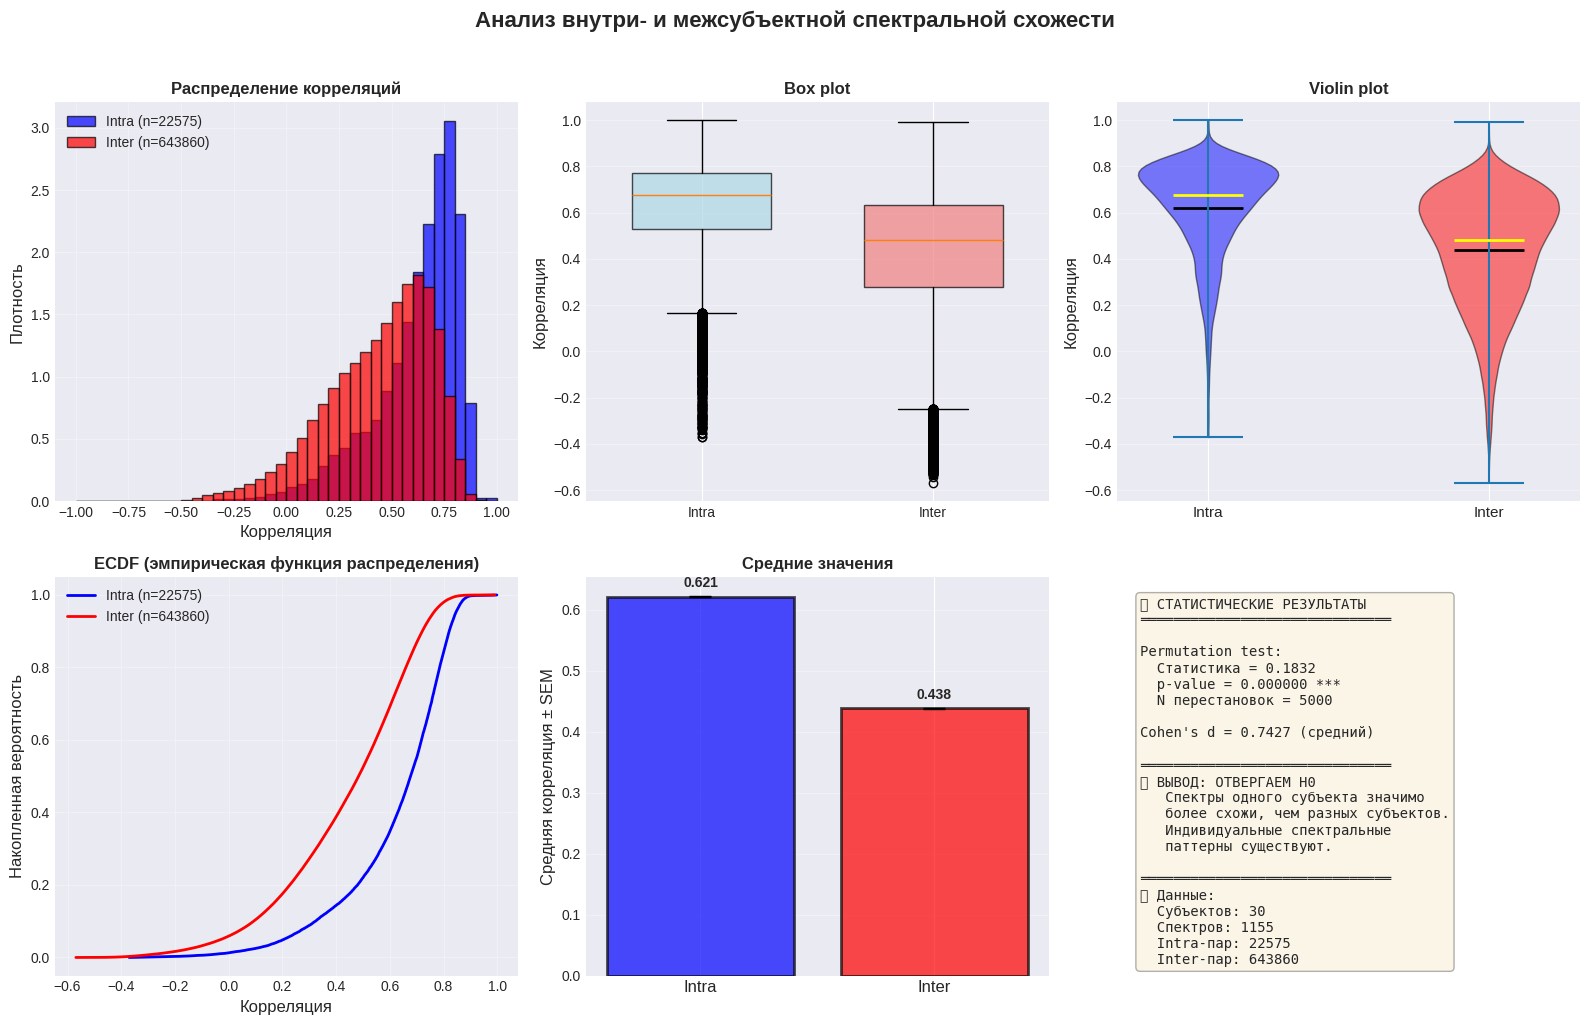

In [9]:
def visualize_permutation_test(results):
    """Визуализация результатов permutation test"""
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Гистограмма распределения перестановок
    ax1 = axes[0]
    perm_stats = results['distribution']
    obs_stat = results['statistic']
    
    # Строим гистограмму
    ax1.hist(perm_stats, bins=30, alpha=0.7, color='skyblue', 
             edgecolor='black', density=True, label='Распределение перестановок')
    
    # Вертикальные линии
    ax1.axvline(obs_stat, color='red', linewidth=2.5, 
                label=f'Наблюдаемая статистика: {obs_stat:.4f}')
    
    # 95% доверительный интервал
    lower = np.percentile(perm_stats, 2.5)
    upper = np.percentile(perm_stats, 97.5)
    ax1.axvline(lower, color='blue', linestyle='--', alpha=0.7, 
                label=f'95% CI: [{lower:.4f}, {upper:.4f}]')
    ax1.axvline(upper, color='blue', linestyle='--', alpha=0.7)
    
    # Среднее распределения
    mean_perm = np.mean(perm_stats)
    ax1.axvline(mean_perm, color='green', linestyle=':', alpha=0.7, 
                label=f'Среднее перестановок: {mean_perm:.4f}')
    
    ax1.set_xlabel('Статистика (среднее intra - среднее inter)', fontsize=12)
    ax1.set_ylabel('Плотность', fontsize=12)
    ax1.set_title(f'Распределение перестановок\n'
                  f'p-value = {results["p_value"]:.6f}', 
                  fontsize=12, fontweight='bold')
    ax1.legend(loc='upper right', fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # 2. QQ-plot
    ax2 = axes[1]
    stats.probplot(perm_stats, dist="norm", plot=ax2)
    ax2.set_title('Q-Q plot (проверка нормальности)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Теоретические квантили', fontsize=11)
    ax2.set_ylabel('Квантили распределения перестановок', fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle('Permutation Test Results\n(перемешивание меток субъектов)', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return fig

# Визуализируем
viz_perm = visualize_permutation_test(results)

# %% [markdown]
# ### Финальная визуализация

def visualize_final_results(results):
    """Финальная визуализация всех результатов"""
    
    intra_corrs = results['intra_corrs']
    inter_corrs = results['inter_corrs']
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    # 1. Гистограммы
    ax1 = axes[0, 0]
    bins = np.linspace(-1, 1, 41)
    ax1.hist(intra_corrs, bins=bins, alpha=0.7, 
             label=f'Intra (n={len(intra_corrs)})', 
             density=True, color='blue', edgecolor='black')
    ax1.hist(inter_corrs, bins=bins, alpha=0.7, 
             label=f'Inter (n={len(inter_corrs)})', 
             density=True, color='red', edgecolor='black')
    ax1.set_xlabel('Корреляция', fontsize=12)
    ax1.set_ylabel('Плотность', fontsize=12)
    ax1.set_title('Распределение корреляций', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Box plot
    ax2 = axes[0, 1]
    bp = ax2.boxplot([intra_corrs, inter_corrs], 
                     tick_labels=['Intra', 'Inter'], 
                     patch_artist=True, widths=0.6)
    colors = ['lightblue', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax2.set_ylabel('Корреляция', fontsize=12)
    ax2.set_title('Box plot', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 3. Violin plot
    ax3 = axes[0, 2]
    parts = ax3.violinplot([intra_corrs, inter_corrs], 
                           showmeans=True, showmedians=True)
    colors = ['blue', 'red']
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.5)
        pc.set_edgecolor('black')
    parts['cmeans'].set_colors('black')
    parts['cmeans'].set_linewidth(2)
    parts['cmedians'].set_colors('yellow')
    parts['cmedians'].set_linewidth(2)
    ax3.set_xticks([1, 2])
    ax3.set_xticklabels(['Intra', 'Inter'], fontsize=11)
    ax3.set_ylabel('Корреляция', fontsize=12)
    ax3.set_title('Violin plot', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # 4. ECDF
    ax4 = axes[1, 0]
    intra_sorted = np.sort(intra_corrs)
    inter_sorted = np.sort(inter_corrs)
    intra_ecdf = np.arange(1, len(intra_sorted) + 1) / len(intra_sorted)
    inter_ecdf = np.arange(1, len(inter_sorted) + 1) / len(inter_sorted)
    
    ax4.plot(intra_sorted, intra_ecdf, color='blue', linewidth=2, 
             label=f'Intra (n={len(intra_corrs)})')
    ax4.plot(inter_sorted, inter_ecdf, color='red', linewidth=2, 
             label=f'Inter (n={len(inter_corrs)})')
    ax4.set_xlabel('Корреляция', fontsize=12)
    ax4.set_ylabel('Накопленная вероятность', fontsize=12)
    ax4.set_title('ECDF (эмпирическая функция распределения)', 
                  fontsize=12, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # 5. Средние с ошибками
    ax5 = axes[1, 1]
    means = [np.mean(intra_corrs), np.mean(inter_corrs)]
    sems = [np.std(intra_corrs, ddof=1)/np.sqrt(len(intra_corrs)), 
            np.std(inter_corrs, ddof=1)/np.sqrt(len(inter_corrs))]
    
    bars = ax5.bar([0, 1], means, yerr=sems, capsize=8, 
                   color=['blue', 'red'], alpha=0.7, 
                   edgecolor='black', linewidth=2)
    ax5.set_xticks([0, 1])
    ax5.set_xticklabels(['Intra', 'Inter'], fontsize=12)
    ax5.set_ylabel('Средняя корреляция ± SEM', fontsize=12)
    ax5.set_title('Средние значения', fontsize=12, fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='y')
    
    # Добавляем значения над барами
    for bar, mean, sem in zip(bars, means, sems):
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height + sem + 0.01,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # 6. Текст с результатами
    ax6 = axes[1, 2]
    ax6.axis('off')
    
    text = "📊 СТАТИСТИЧЕСКИЕ РЕЗУЛЬТАТЫ\n" + "═"*30 + "\n\n"
    
    # Permutation test
    p = results['p_value']
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    text += f"Permutation test:\n"
    text += f"  Статистика = {results['statistic']:.4f}\n"
    text += f"  p-value = {p:.6f} {sig}\n"
    text += f"  N перестановок = {results['n_permutations']}\n\n"
    
    # Cohen's d
    n1, n2 = len(intra_corrs), len(inter_corrs)
    var1, var2 = np.var(intra_corrs, ddof=1), np.var(inter_corrs, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    cohens_d = (np.mean(intra_corrs) - np.mean(inter_corrs)) / pooled_std if pooled_std > 0 else 0
    
    if abs(cohens_d) >= 0.8:
        effect_desc = "большой"
    elif abs(cohens_d) >= 0.5:
        effect_desc = "средний"
    elif abs(cohens_d) >= 0.2:
        effect_desc = "малый"
    else:
        effect_desc = "незначительный"
    
    text += f"Cohen's d = {cohens_d:.4f} ({effect_desc})\n\n"
    
    text += "═"*30 + "\n"
    
    if p < 0.05:
        text += "✅ ВЫВОД: ОТВЕРГАЕМ H0\n"
        text += "   Спектры одного субъекта значимо\n"
        text += "   более схожи, чем разных субъектов.\n"
        text += "   Индивидуальные спектральные\n"
        text += "   паттерны существуют."
    else:
        text += "❌ ВЫВОД: НЕ ОТВЕРГАЕМ H0\n"
        text += "   Нет значимых различий между\n"
        text += "   внутри- и межсубъектной\n"
        text += "   схожестью спектров."
    
    text += "\n\n" + "═"*30 + "\n"
    text += f"📈 Данные:\n"
    text += f"  Субъектов: {len(np.unique(results['subject_ids']))}\n"
    text += f"  Спектров: {len(results['subject_ids'])}\n"
    text += f"  Intra-пар: {len(intra_corrs)}\n"
    text += f"  Inter-пар: {len(inter_corrs)}"
    
    ax6.text(0.05, 0.95, text, fontfamily='monospace', fontsize=10,
             verticalalignment='top', transform=ax6.transAxes,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.suptitle('Анализ внутри- и межсубъектной спектральной схожести', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return fig

# Визуализируем финальные результаты
viz_final = visualize_final_results(results)


In [10]:
def create_topomap_plots(spectra_list, subject_ids, freqs, n_channels=63):
    """
    Создает топомапы для внутрисубъектных и межсубъектных различий
    
    Args:
        spectra_list: список спектров (n_channels, n_frequencies)
        subject_ids: идентификаторы субъектов
        freqs: частоты
        n_channels: количество каналов
    """
    print("\nCreating topomap visualizations...")
    
    # Проверяем, есть ли многоканальные данные
    if len(spectra_list) == 0 or spectra_list[0].ndim == 1:
        print("  Warning: No multi-channel data available for topomaps")
        return
    
    # Определяем частотные диапазоны
    freq_bands = {
        'Delta (1-4 Hz)': (1, 4),
        'Theta (4-8 Hz)': (4, 8),
        'Alpha (8-13 Hz)': (8, 13),
        'Beta (13-30 Hz)': (13, 30)
    }
    
    # Создаем фигуру для топомапов
    n_bands = len(freq_bands)
    fig, axes = plt.subplots(3, n_bands, figsize=(4*n_bands, 10))
    if n_bands == 1:
        axes = axes.reshape(3, 1)
    
    # Создаем упрощенную информацию о каналах для 63-канальной системы
    print("  Creating montage for 63-channel EEG system...")
    
    # Стандартные названия каналов для 63-канальной системы
    # Базовый набор каналов 10-20 системы
    standard_channels = [
        'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FT7', 'FC3', 'FCz', 
        'FC4', 'FT8', 'T7', 'C3', 'Cz', 'C4', 'T8', 'TP7', 'CP3', 'CPz', 
        'CP4', 'TP8', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'O2', 'Oz'
    ]
    
    # Добавляем дополнительные каналы для 63-канальной системы
    extra_channels = [
        'Fpz', 'AF7', 'AF3', 'AF4', 'AF8', 'F5', 'F1', 'F2', 'F6', 'FC5',
        'FC1', 'FC2', 'FC6', 'C5', 'C1', 'C2', 'C6', 'CP5', 'CP1', 'CP2',
        'CP6', 'P5', 'P1', 'P2', 'P6', 'PO7', 'PO3', 'POz', 'PO4', 'PO8',
        'FT9', 'FT10', 'TP9', 'TP10'
    ]
    
    # Объединяем каналы
    ch_names = standard_channels + extra_channels
    # Берем только первые n_channels каналов
    ch_names = ch_names[:n_channels]
    
    # Создаем info
    info = mne.create_info(ch_names=ch_names, sfreq=250, ch_types='eeg')
    
    # Создаем кастомный montage
    try:
        montage = mne.channels.make_standard_montage('standard_1020')
        montage_ch_names = list(montage.ch_names)
        ch_pos = {}
        
        # Сопоставляем наши каналы с каналами в montage
        for ch in ch_names:
            if ch in montage_ch_names:
                ch_pos[ch] = montage.get_positions()['ch_pos'][ch]
            else:
                # Для каналов, которых нет в стандартном montage
                print(f"    Warning: Channel {ch} not in standard montage, using approximate position")
                ch_pos[ch] = np.array([0, 0, 0])  # Временная позиция
        
        # Создаем кастомный montage
        montage = mne.channels.make_dig_montage(ch_pos=ch_pos)
        info.set_montage(montage)
        print(f"    Created montage with {len(ch_pos)} channels")
        
    except Exception as e:
        print(f"    Error creating montage: {e}")
        print("    Using spherical layout without specific montage")
    
    # Группируем данные по субъектам
    unique_subjects = np.unique(subject_ids)
    subject_groups = {}
    
    for subj in unique_subjects:
        subject_indices = np.where(subject_ids == subj)[0]
        if len(subject_indices) >= 2:  # Нужно хотя бы 2 сессии для внутрисубъектного анализа
            subject_groups[subj] = [spectra_list[i] for i in subject_indices]
    
    # Для каждого частотного диапазона вычисляем средние различия
    for band_idx, (band_name, (low_freq, high_freq)) in enumerate(freq_bands.items()):
        print(f"  Processing {band_name}...")
        
        # Создаем маску для частотного диапазона
        freq_mask = (freqs >= low_freq) & (freqs < high_freq)
        
        # Вычисляем внутрисубъектные различия
        intra_diffs = []
        for subj, subj_spectra in subject_groups.items():
            if len(subj_spectra) >= 2:
                # Усредняем по частотам в диапазоне для каждого канала
                band_spectra = [np.mean(spec[:, freq_mask], axis=1) for spec in subj_spectra]
                # Вычисляем стандартное отклонение между сессиями для каждого канала
                if len(band_spectra) > 1:
                    band_array = np.array(band_spectra)  # (n_sessions, n_channels)
                    # Берем только первые n_channels каналов для совместимости с info
                    n_plot_channels = min(band_array.shape[1], len(info['ch_names']))
                    subj_std = np.std(band_array[:, :n_plot_channels], axis=0)
                    intra_diffs.append(subj_std)
        
        # Вычисляем межсубъектные различия
        inter_diffs = []
        subject_means = []
        for subj, subj_spectra in subject_groups.items():
            if len(subj_spectra) >= 1:
                # Усредняем по частотам и по сессиям для каждого субъекта
                band_spectra = [np.mean(spec[:, freq_mask], axis=1) for spec in subj_spectra]
                n_plot_channels = min(band_spectra[0].shape[0], len(info['ch_names']))
                band_spectra_trimmed = [spec[:n_plot_channels] for spec in band_spectra]
                subj_mean = np.mean(band_spectra_trimmed, axis=0)
                subject_means.append(subj_mean)
        
        if len(subject_means) >= 2:
            subject_means_array = np.array(subject_means)  # (n_subjects, n_channels)
            n_plot_channels = min(subject_means_array.shape[1], len(info['ch_names']))
            inter_std = np.std(subject_means_array[:, :n_plot_channels], axis=0)
            inter_diffs = inter_std
        
        # Преобразуем в массивы для визуализации
        n_plot_channels = len(info['ch_names'])
        
        if intra_diffs:
            intra_array = np.array(intra_diffs)
            # Обрезаем или дополняем до нужного количества каналов
            if intra_array.shape[1] >= n_plot_channels:
                intra_mean = np.abs(np.mean(intra_array[:, :n_plot_channels], axis=0))
            else:
                intra_mean = np.zeros(n_plot_channels)
                intra_mean[:intra_array.shape[1]] = np.abs(np.mean(intra_array, axis=0))
        else:
            intra_mean = np.zeros(n_plot_channels)
        
        if len(inter_diffs) > 0:
            if len(inter_diffs) >= n_plot_channels:
                inter_mean = inter_diffs[:n_plot_channels]
            else:
                inter_mean = np.zeros(n_plot_channels)
                inter_mean[:len(inter_diffs)] = np.abs(inter_diffs)
        else:
            inter_mean = np.abs(np.zeros(n_plot_channels))
        
        # Вычисляем разницу (красный - синий)
        diff_mean = inter_mean - intra_mean

        
        # Функция для симметричных пределов цвета
        def sym_vlim(v):
            vmax = np.nanmax(np.abs(v))
            return (-vmax, vmax) if np.isfinite(vmax) and vmax > 0 else (-1, 1)
        
        # 1. Внутрисубъектные различия (синий)
        ax1 = axes[0, band_idx]
        if np.any(intra_mean != 0):
            try:
                # Используем правильный API для plot_topomap
                im1, _ = mne.viz.plot_topomap(intra_mean, info, axes=ax1, show=False, 
                                             cmap='Blues', contours=0, sensors=True)
                ax1.set_title(f'{band_name}\nIntra-subject\nVariability', fontsize=10)
            except Exception as e:
                print(f"    Error plotting intra-subject topomap: {e}")
                ax1.text(0.5, 0.5, 'Plot error', transform=ax1.transAxes, 
                        ha='center', va='center')
                ax1.set_title(f'{band_name}\nIntra-subject\n(Error)', fontsize=10)
        else:
            ax1.text(0.5, 0.5, 'No data', transform=ax1.transAxes, 
                    ha='center', va='center')
            ax1.set_title(f'{band_name}\nIntra-subject\n(No data)', fontsize=10)
        
        # 2. Межсубъектные различия (красный)
        ax2 = axes[1, band_idx]
        if np.any(inter_mean != 0):
            try:
                im2, _ = mne.viz.plot_topomap(inter_mean, info, axes=ax2, show=False, 
                                             cmap='Reds', contours=0, sensors=True)
                ax2.set_title(f'{band_name}\nInter-subject\nVariability', fontsize=10)
            except Exception as e:
                print(f"    Error plotting inter-subject topomap: {e}")
                ax2.text(0.5, 0.5, 'Plot error', transform=ax2.transAxes, 
                        ha='center', va='center')
                ax2.set_title(f'{band_name}\nInter-subject\n(Error)', fontsize=10)
        else:
            ax2.text(0.5, 0.5, 'No data', transform=ax2.transAxes, 
                    ha='center', va='center')
            ax2.set_title(f'{band_name}\nInter-subject\n(No data)', fontsize=10)
        
        # 3. Разница (красный - синий) с симметричной цветовой шкалой
        ax3 = axes[2, band_idx]
        if np.any(diff_mean != 0):
            try:
                vlim = sym_vlim(diff_mean)
                im3, _ = mne.viz.plot_topomap(diff_mean, info, axes=ax3, show=False, 
                                             cmap='RdBu_r', contours=0, sensors=True)
                ax3.set_title(f'{band_name}\nDifference\n(Inter - Intra)', fontsize=10)
            except Exception as e:
                print(f"    Error plotting difference topomap: {e}")
                ax3.text(0.5, 0.5, 'Plot error', transform=ax3.transAxes, 
                        ha='center', va='center')
                ax3.set_title(f'{band_name}\nDifference\n(Error)', fontsize=10)
        else:
            ax3.text(0.5, 0.5, 'No data', transform=ax3.transAxes, 
                    ha='center', va='center')
            ax3.set_title(f'{band_name}\nDifference\n(No data)', fontsize=10)
    
    # Добавляем заголовки для столбцов
    axes[0, 0].set_ylabel('Intra-subject\n(Blue)', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Inter-subject\n(Red)', fontsize=12, fontweight='bold')
    axes[2, 0].set_ylabel('Difference\n(Red-Blue)', fontsize=12, fontweight='bold')
    
    plt.suptitle('Topographic Distribution of Spectral Variability\n'
                'Blue: Intra-subject variability | Red: Inter-subject variability | Difference: Inter - Intra', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return fig



🔄 Нормализация FFT-данных (метод: channel)...
  ✅ Нормализация завершена
  Диапазон значений после нормализации: [-0.56, 327.33]

Creating topomap visualizations...
  Creating montage for 63-channel EEG system...
    Created montage with 63 channels
  Processing Delta (1-4 Hz)...
  Processing Theta (4-8 Hz)...
  Processing Alpha (8-13 Hz)...
  Processing Beta (13-30 Hz)...


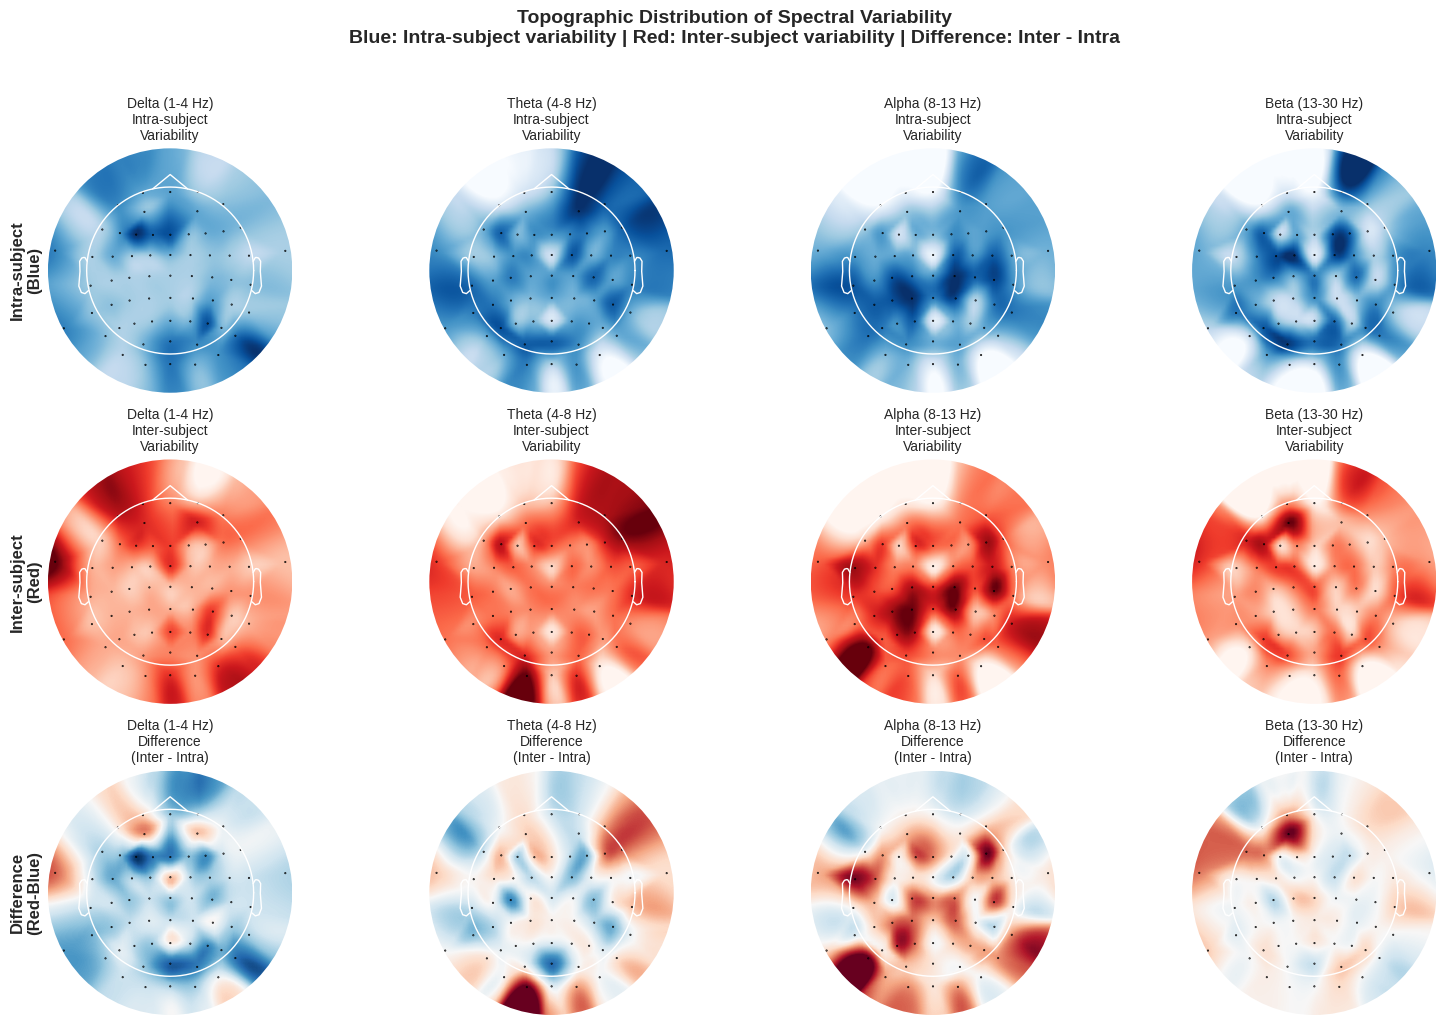


Creating topomap visualizations...
  Creating montage for 63-channel EEG system...
    Created montage with 63 channels
  Processing Delta (1-4 Hz)...
  Processing Theta (4-8 Hz)...
  Processing Alpha (8-13 Hz)...
  Processing Beta (13-30 Hz)...


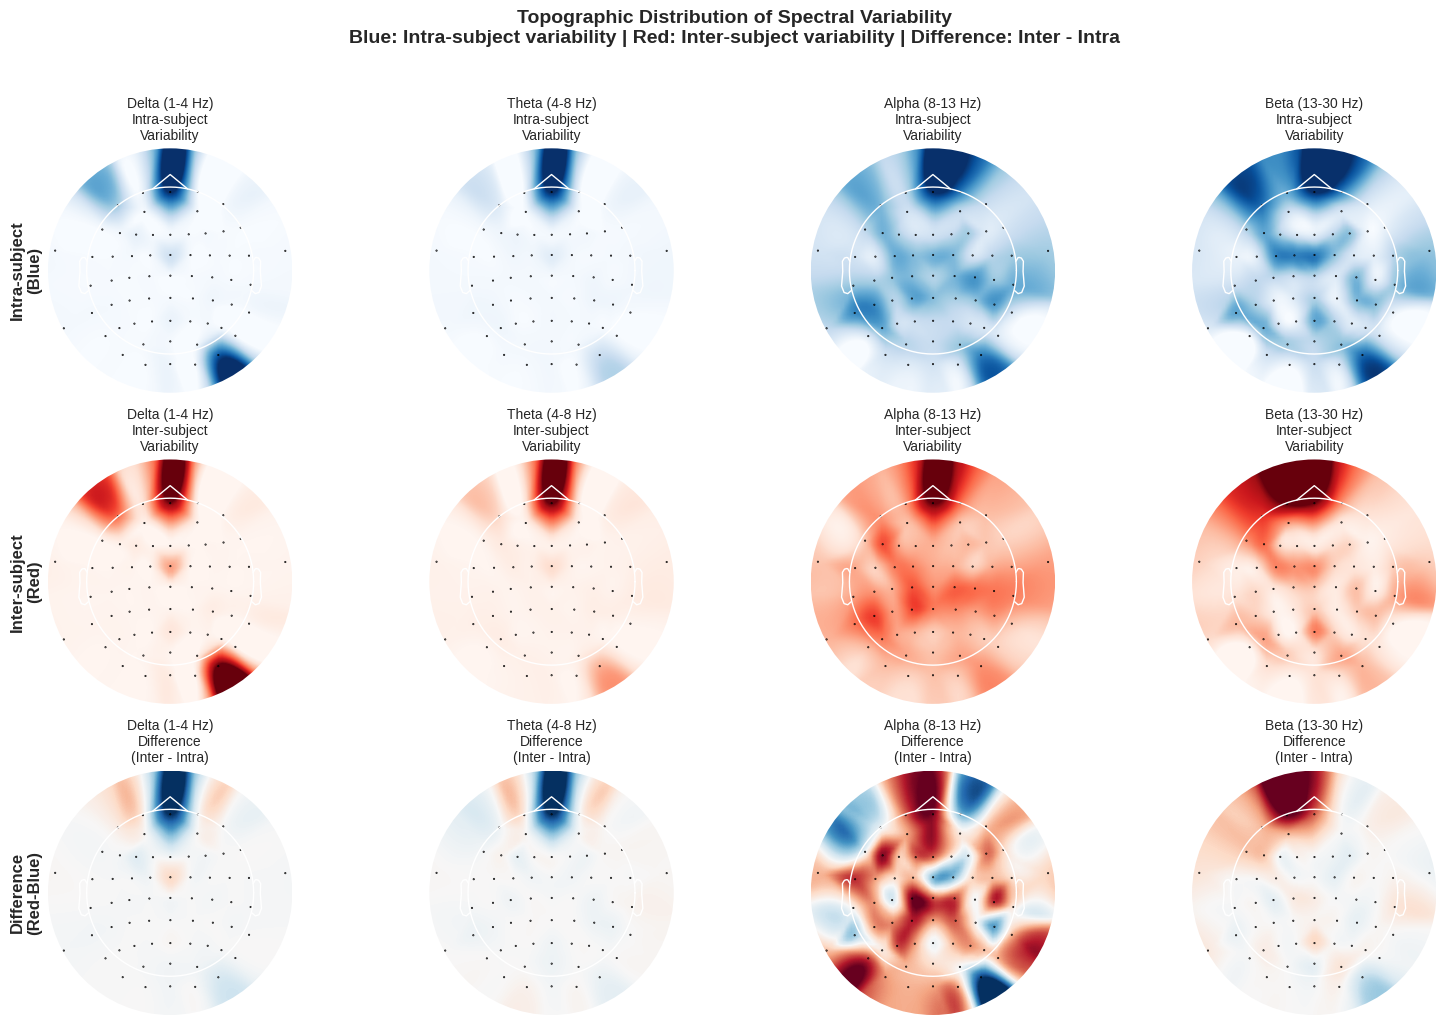

In [11]:
def normalize_fft_data(spectra, method='channel'):
    """
    Нормализация FFT-данных
    
    Parameters:
    -----------
    spectra : array (n_samples, n_channels, n_freqs)
        Исходные FFT-данные
    method : str
        'channel' - нормализация по каналам
        'frequency' - нормализация по частотам
        'global' - глобальная нормализация
    """
    print(f"\n🔄 Нормализация FFT-данных (метод: {method})...")
    
    spectra_norm = spectra.copy()
    
    if method == 'channel':
        # Нормализуем каждый канал отдельно
        for ch in range(spectra.shape[1]):
            ch_mean = np.mean(spectra[:, ch, :])
            ch_std = np.std(spectra[:, ch, :])
            if ch_std > 0:
                spectra_norm[:, ch, :] = (spectra[:, ch, :] - ch_mean) / ch_std
    
    elif method == 'frequency':
        # Нормализуем каждую частоту отдельно
        for freq in range(spectra.shape[2]):
            freq_mean = np.mean(spectra[:, :, freq])
            freq_std = np.std(spectra[:, :, freq])
            if freq_std > 0:
                spectra_norm[:, :, freq] = (spectra[:, :, freq] - freq_mean) / freq_std
    
    elif method == 'global':
        # Глобальная нормализация
        global_mean = np.mean(spectra)
        global_std = np.std(spectra)
        print(global_mean)
        if global_std > 0:
            spectra_norm = (spectra - global_mean) / global_std

    
    print(f"  ✅ Нормализация завершена")
    print(f"  Диапазон значений после нормализации: [{np.min(spectra_norm):.2f}, {np.max(spectra_norm):.2f}]")
    
    return spectra_norm

# Попробуйте нормализовать данные
spectra_normalized = normalize_fft_data(spectra, method='channel')

# Затем используйте нормализованные данные для топомапов
topomap_fig = create_topomap_plots(spectra_normalized, subject_ids, freqs, n_channels)

topomap_fig = create_topomap_plots(spectra, subject_ids, freqs, n_channels)

In [12]:
ch_names = create_channel_names(n_channels)
print(f"Канал на позиции 30: {ch_names[30]}")
print(f"Все каналы:")
for i, ch in enumerate(ch_names[:35]):
    print(f"  {i}: {ch}")

NameError: name 'create_channel_names' is not defined